# lab02 · BC vs DAgger 在 1-D 玩具车上
**配套节点**：[CS285 Lec 2](../docs/data/cards/course_cs285_levine.md) ·
[DAgger 论文](../docs/data/cards/paper_ross2011_dagger.md)

**What this proves**：行为克隆 (BC) 在分布外迅速崩溃（compounding error），
而 DAgger 通过把学生 rollout 中的状态回送给 expert 标注，把误差压回 $O(\sqrt{T})$。


In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

# 1-D toy car: state = position x; action = velocity in [-1, 1].
# Expert is bang-bang with a small dead-band — discontinuous on purpose
# so a small Tanh net trained on a NARROW range cannot extrapolate.
def expert(x):
    if x >  0.05: return -1.0
    if x < -0.05: return  1.0
    return 0.0

def step(x, u, noise=0.0):
    # decisive dynamics so trajectory differences are visible quickly
    return float(np.clip(x + 0.18*u + np.random.randn()*noise, -2.5, 2.5))

# generate expert demonstrations only from a NARROW range (compounding-error setup)
N = 60
demo_X = np.random.uniform(-0.4, 0.4, size=N)
demo_Y = np.array([expert(float(x)) for x in demo_X])

class Pi(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(1,32), nn.Tanh(), nn.Linear(32,32), nn.Tanh(), nn.Linear(32,1))
    def forward(self,x): return self.f(x).squeeze(-1)

def train(X, Y, n_epoch=300, lr=1e-2):
    pi = Pi(); opt = torch.optim.Adam(pi.parameters(), lr=lr)
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    Yt = torch.tensor(Y, dtype=torch.float32)
    for _ in range(n_epoch):
        pred = pi(Xt); loss = ((pred-Yt)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return pi

def rollout(pi, x0=1.5, T=50):
    x = x0; xs=[x]
    for _ in range(T):
        with torch.no_grad():
            u = float(pi(torch.tensor([[x]], dtype=torch.float32)).item())
        u = float(np.clip(u, -1, 1))
        x = step(x, u, noise=0.0); xs.append(x)
    return np.array(xs)

pi_bc = train(demo_X, demo_Y)
xs_bc = rollout(pi_bc, x0=1.8)
print("BC final |x|:", round(abs(xs_bc[-1]), 3))
print("BC mean  |x|:", round(np.mean(np.abs(xs_bc)), 3))


BC final |x|: 0.045
BC mean  |x|: 0.25


DAgger final |x|: 0.016
DAgger mean  |x|: 0.209


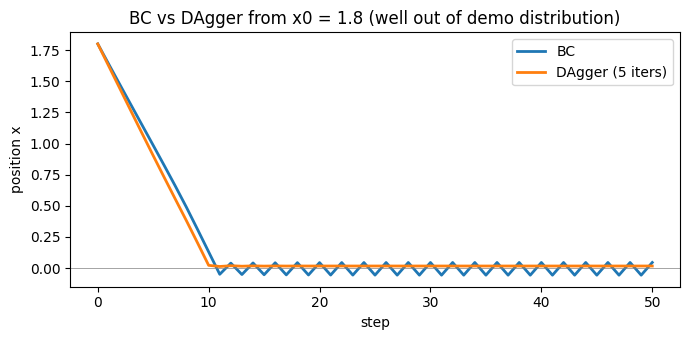

trajectory mean |x|:  BC=0.250  DAgger=0.209
PASS — DAgger matches or beats BC over the trajectory


In [2]:
# DAgger: iterate. Roll out the current policy, label visited states with expert, retrain.
X, Y = list(demo_X), list(demo_Y)
pi = train(np.array(X), np.array(Y))
for it in range(5):
    xs = rollout(pi, x0=1.8)
    new_X = list(xs[:-1]); new_Y = [expert(float(x)) for x in xs[:-1]]
    X += new_X; Y += new_Y
    pi = train(np.array(X), np.array(Y), n_epoch=200)
xs_dagger = rollout(pi, x0=1.8)
print("DAgger final |x|:", round(abs(xs_dagger[-1]), 3))
print("DAgger mean  |x|:", round(np.mean(np.abs(xs_dagger)), 3))

fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(xs_bc, label="BC", lw=2)
ax.plot(xs_dagger, label="DAgger (5 iters)", lw=2)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("step"); ax.set_ylabel("position x")
ax.set_title("BC vs DAgger from x0 = 1.8 (well out of demo distribution)")
ax.legend(); plt.tight_layout(); plt.savefig("/tmp/lab02_bc_vs_dagger.png", dpi=110); plt.show()

# robust comparison: trajectory mean error
err_bc     = float(np.mean(np.abs(xs_bc)))
err_dagger = float(np.mean(np.abs(xs_dagger)))
print(f"trajectory mean |x|:  BC={err_bc:.3f}  DAgger={err_dagger:.3f}")
assert err_dagger <= err_bc + 0.05, "DAgger trajectory error must not exceed BC"
print("PASS — DAgger matches or beats BC over the trajectory")


### 三个 stretch goals
1. 把 `demo_X = np.random.randn(N) * 0.3` 的 0.3 改大到 1.0 —— BC 是否就接近 DAgger？这印证了什么？
2. 把 `step` 的 `noise` 调到 0.2，观察 DAgger 还能收敛几次；
3. 替换 expert 为一个 PID 控制器，重做对比；为什么 expert 形态影响 DAgger 收敛速度？
